In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 200)

In [4]:
healthcare_df = pd.read_excel('../data/interim/healthcare_cleaned.xlsx')
healthcare_df.head(10)

,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Age,Gender,Marital Status,Children,Employment Status,Monthly Household Income,Health_Insurance,Insurance_cover,Last_Hosptal_visit,Last_Hosptal_visit_insurance,Check-up,Years_to_Checkup,Cancer_Screening,Years_to_Screening
0,-0.715812,37.147506,1361.900024,20.000,18-30,Male,Single,0,Unemployed,Less than 10000,No,NaN,8.0,No,Yes,1,No,NaN
1,-0.715816,37.147508,1361.900024,20.000,41-50,Female,Married,5,Self-employed,20001-30000,No,NaN,6.0,Yes,No,NaN,Yes,4+
2,-0.715708,37.147490,1361.900024,20.000,18-30,Male,Single,0,Self-employed,10001-20000,Yes,NHIF,16.0,Yes,No,NaN,No,NaN
3,-0.715734,37.147480,1361.900024,20.000,41-50,Male,Married,7,Self-employed,20001-30000,Yes,NHIF,13.0,Yes,No,NaN,Yes,4+
4,-0.715804,37.147536,1361.900024,26.107,18-30,Female,Single,0,Unemployed,10001-20000,Yes,NHIF,2.0,Yes,No,NaN,No,NaN
5,-0.715893,37.147353,1361.599976,32.483,31-40,Female,Married,2,Self-employed,10001-20000,Yes,NHIF,4.0,Yes,No,NaN,No,NaN
6,-0.715940,37.146309,1362.200073,56.100,18-30,Male,Single,0,Self-employed,Less than 10000,No,NaN,24.0,No,No,NaN,No,NaN
7,-0.715912,37.147077,1362.200073,33.011,31-40,Female,Married,3,Employed,20001-30000,Yes,NHIF,5.0,Yes,No,NaN,No,NaN
8,-0.715871,37.146672,1362.200073,52.400,31-40,Female,Married,2,Employed,10001-20000,Yes,NHIF,6.0,Yes,No,NaN,No,NaN
9,-0.716643,37.145942,1365.800049,98.400,18-30,Male,Single,0,Unemployed,Less than 10000,No,NaN,17.0,No,No,NaN,No,NaN


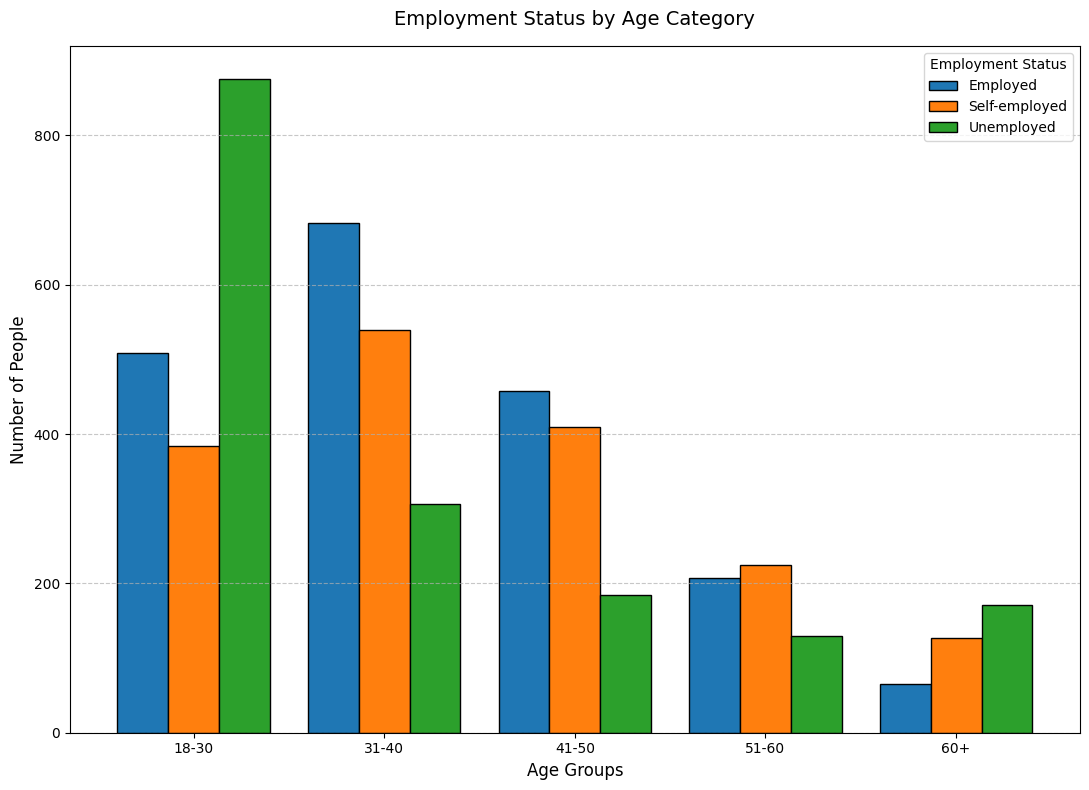

In [16]:
ct = pd.crosstab(healthcare_df['Age'], healthcare_df['Employment Status'])
fig, ax = plt.subplots(figsize=(11, 8))
ct.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')
ax.set_title('Employment Status by Age Category', fontsize=14, pad=15)
ax.set_xlabel('Age Groups', fontsize=12)
ax.set_ylabel('Number of People', fontsize=12)
ax.set_xticklabels(ct.index, rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Employment Status')

plt.tight_layout()
plt.show()

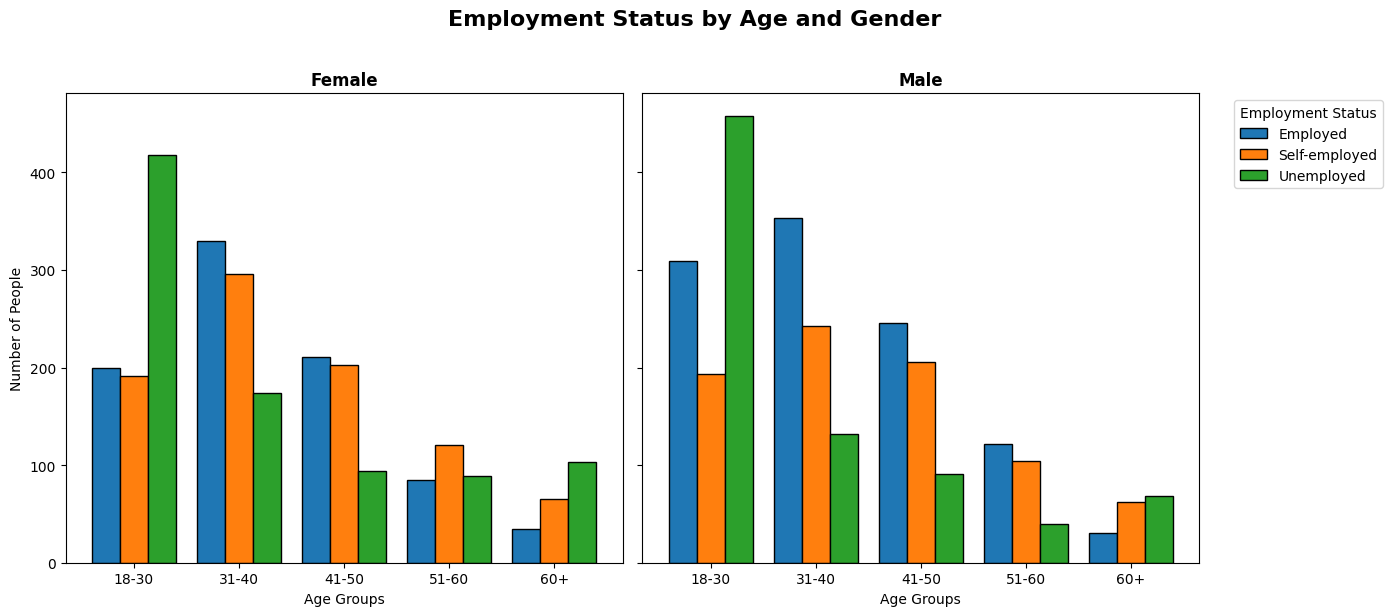

In [10]:
# 1. Separate the data by Gender using Pandas groupby
# This creates a separate cross-tabulation grid for each gender
categories = ['Age', 'Employment Status']
grouped = healthcare_df.groupby('Gender')[categories].value_counts().unstack(fill_value=0)

# 2. Create a figure canvas with 1 row and 2 columns of plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 3. Plot Females on the first plot (axes[0])
if 'Female' in grouped.index.levels[0]:
    grouped.loc['Female'].plot(kind='bar', ax=axes[0], edgecolor='black', width=0.8)
axes[0].set_title('Female', fontsize=12, weight='bold')
axes[0].set_xlabel('Age Groups')
axes[0].set_ylabel('Number of People')
axes[0].get_legend().remove() # Remove legend here to avoid clutter
axes[0].tick_params(axis='x', rotation=0)

# 4. Plot Males on the second plot (axes[1])
if 'Male' in grouped.index.levels[0]:
    grouped.loc['Male'].plot(kind='bar', ax=axes[1], edgecolor='black', width=0.8)
axes[1].set_title('Male', fontsize=12, weight='bold')
axes[1].set_xlabel('Age Groups')
axes[1].tick_params(axis='x', rotation=0)

# 5. Add a single unified legend and a main title
axes[1].legend(title='Employment Status', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.suptitle('Employment Status by Age and Gender', fontsize=16, weight='bold', y=1.02)

plt.tight_layout()
plt.show()



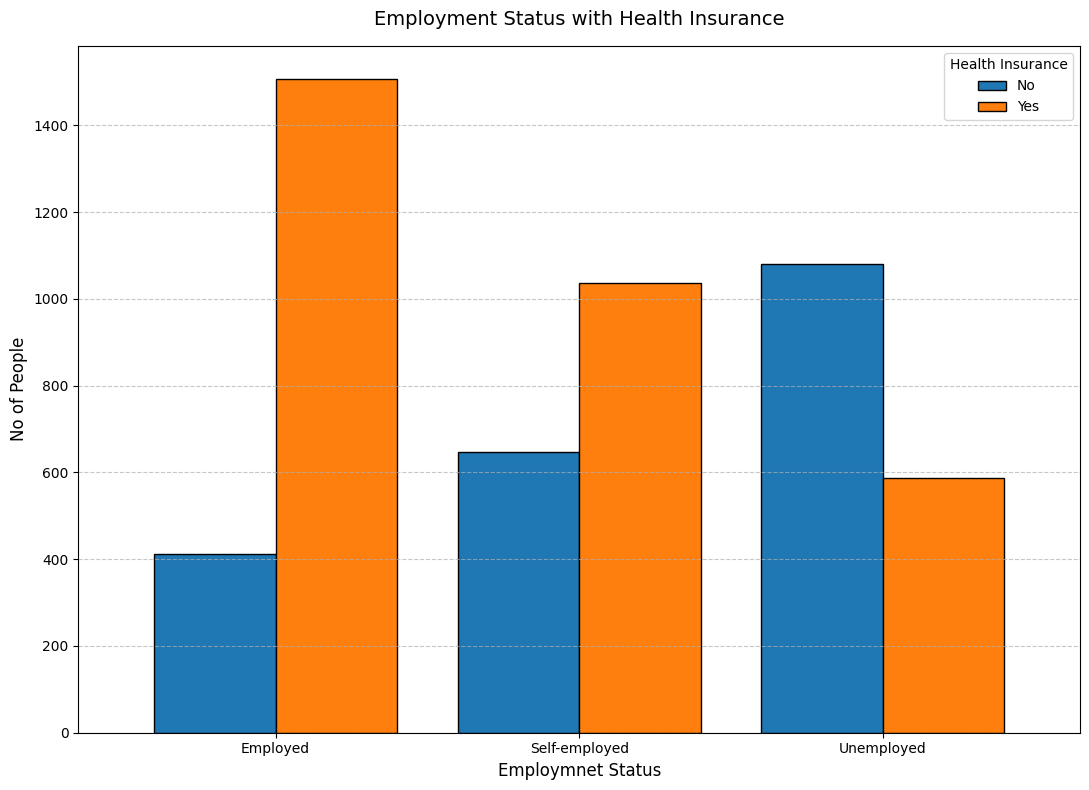

In [15]:
ct = pd.crosstab(healthcare_df['Employment Status'], healthcare_df['Health_Insurance'])
fig, ax = plt.subplots(figsize=(11, 8))
ct.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')
ax.set_title('Employment Status with Health Insurance', fontsize=14, pad=15)
ax.set_xlabel('Employmnet Status', fontsize=12)
ax.set_ylabel('No of People', fontsize=12)
ax.set_xticklabels(ct.index, rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Health Insurance')

plt.tight_layout()
plt.show()

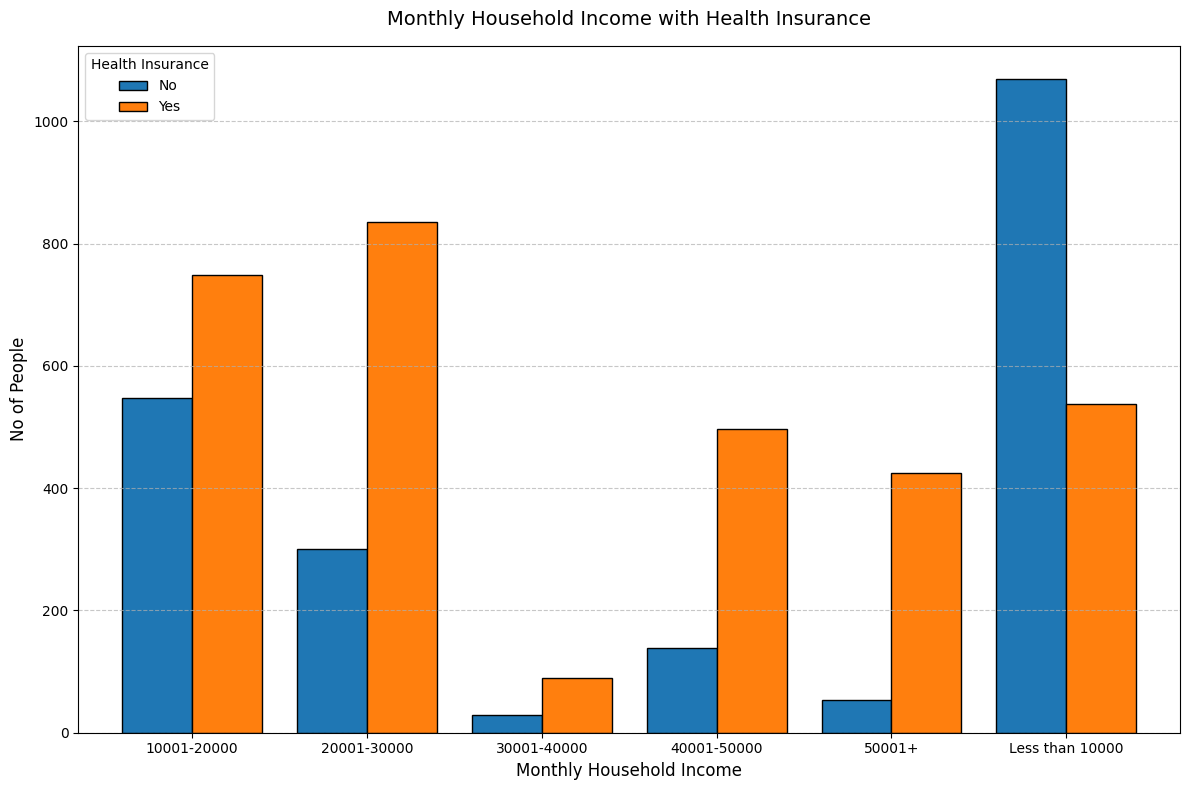

In [14]:
ct = pd.crosstab(healthcare_df['Monthly Household Income'], healthcare_df['Health_Insurance'])
fig, ax = plt.subplots(figsize=(12, 8))
ct.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')
ax.set_title('Monthly Household Income with Health Insurance', fontsize=14, pad=15)
ax.set_xlabel('Monthly Household Income', fontsize=12)
ax.set_ylabel('No of People', fontsize=12)
ax.set_xticklabels(ct.index, rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Health Insurance')

plt.tight_layout()
plt.show()

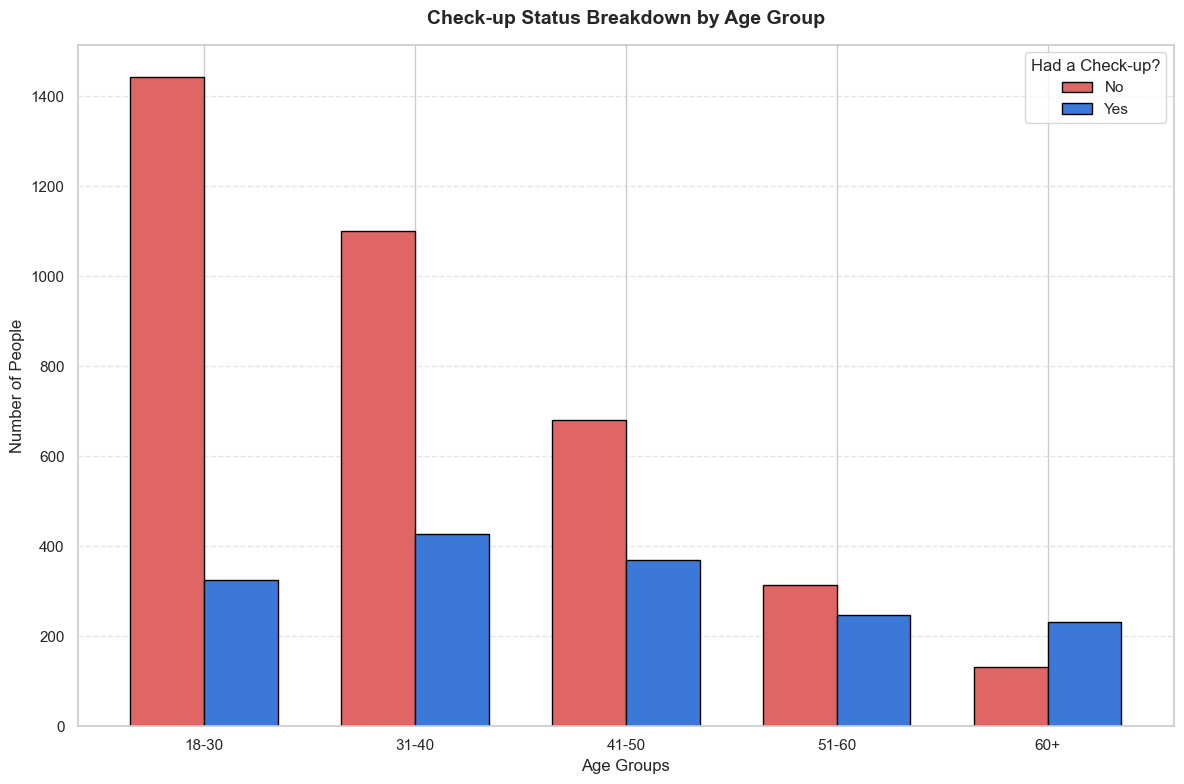

In [29]:
# This calculates the numeric grid counts automatically
checkup_age_ct = pd.crosstab(healthcare_df['Age'], healthcare_df['Check-up'])

# Create the canvas
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the data as side-by-side bars
# Custom colors: Greenish-blue for 'Yes', Soft Red/Orange for 'No'
colors = ['#e06666', '#3c78d8'] if list(checkup_age_ct.columns) == ['No', 'Yes'] else ['#3c78d8', '#e06666']
checkup_age_ct.plot(kind='bar', ax=ax, width=0.7, color=colors, edgecolor='black')

# Add Polish and Labels
ax.set_title('Check-up Status Breakdown by Age Group', fontsize=14, pad=15, weight='bold')
ax.set_xlabel('Age Groups', fontsize=12)
ax.set_ylabel('Number of People', fontsize=12)

# Ensure the age categories on the bottom stay perfectly horizontal
ax.set_xticklabels(checkup_age_ct.index, rotation=0)

# Add background gridlines for easier numeric tracking
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add a clear legend box
ax.legend(title='Had a Check-up?')

plt.tight_layout()
plt.show()

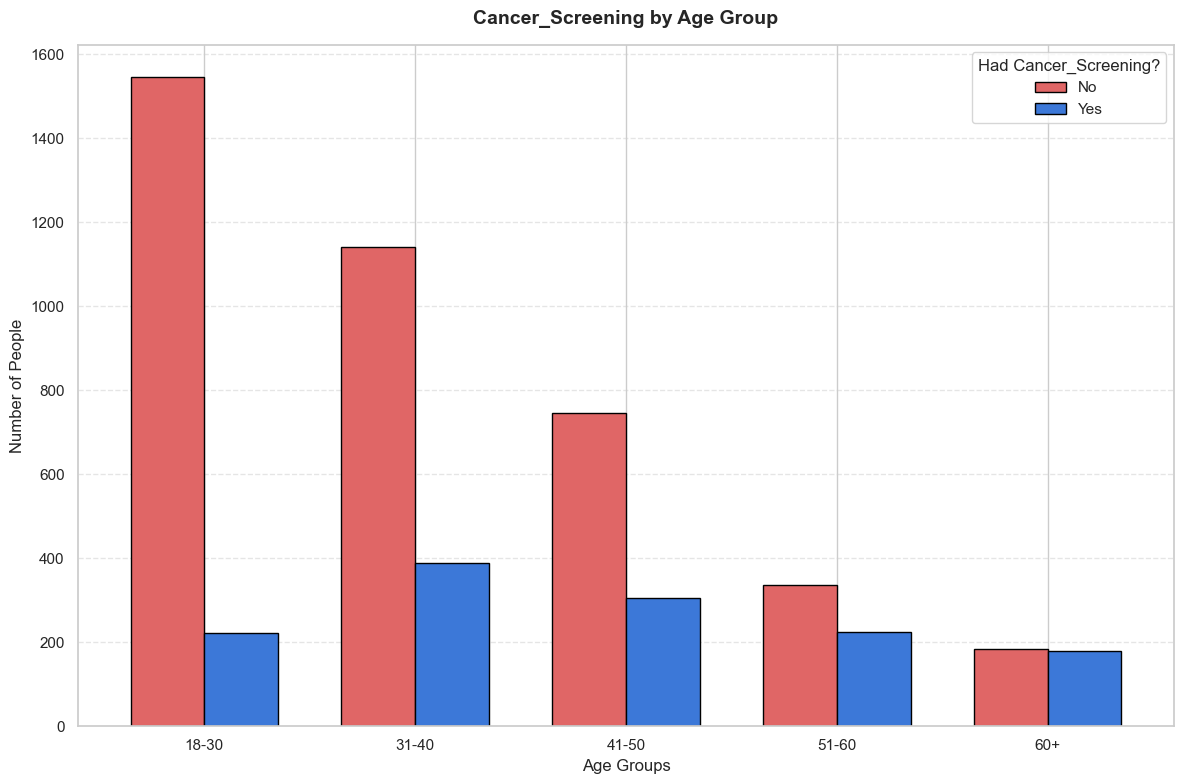

In [30]:
# This calculates the numeric grid counts automatically
checkup_age_ct = pd.crosstab(healthcare_df['Age'], healthcare_df['Cancer_Screening'])

# Create the canvas
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the data as side-by-side bars
# Custom colors: Greenish-blue for 'Yes', Soft Red/Orange for 'No'
colors = ['#e06666', '#3c78d8'] if list(checkup_age_ct.columns) == ['No', 'Yes'] else ['#3c78d8', '#e06666']
checkup_age_ct.plot(kind='bar', ax=ax, width=0.7, color=colors, edgecolor='black')

# Add Polish and Labels
ax.set_title('Cancer_Screening by Age Group', fontsize=14, pad=15, weight='bold')
ax.set_xlabel('Age Groups', fontsize=12)
ax.set_ylabel('Number of People', fontsize=12)

# Ensure the age categories on the bottom stay perfectly horizontal
ax.set_xticklabels(checkup_age_ct.index, rotation=0)

# Add background gridlines for easier numeric tracking
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add a clear legend box
ax.legend(title='Had Cancer_Screening?')

plt.tight_layout()
plt.show()

In [22]:
healthcare_df = pd.read_excel('../data/processed/final_healthcare.xlsx')

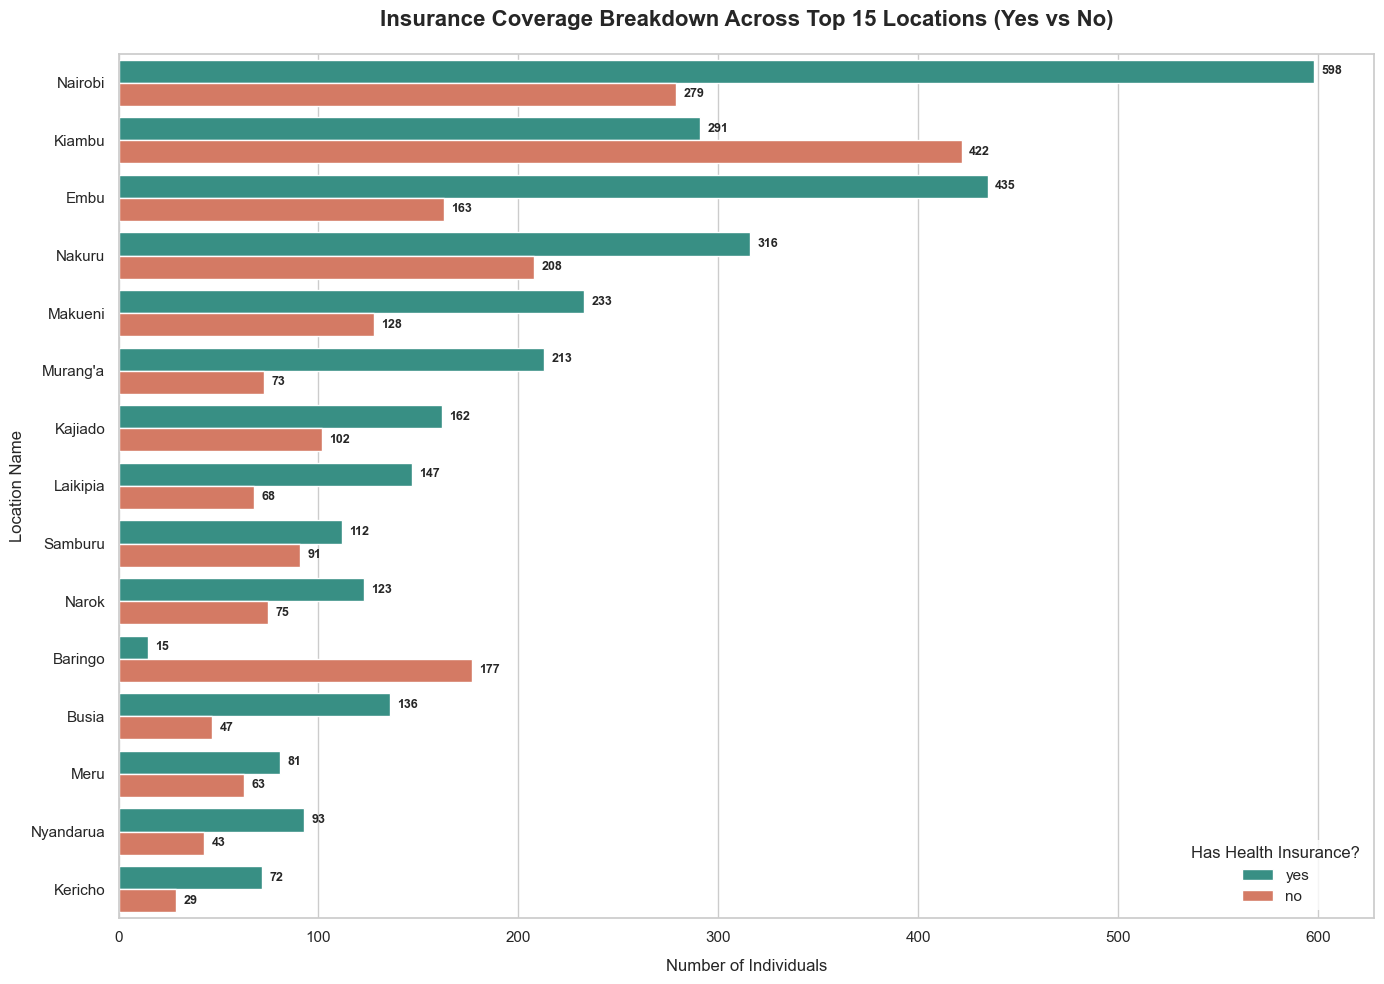

In [28]:
# Set up canvas and clean grid theme
plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid")

# Chain operations to filter missing coordinates, normalize strings, group by location/status, and slice the top 10 populated areas
ax = sns.barplot(
    x='Count',
    y='location_name',
    hue='Health_Insurance',
    data=(
        healthcare_df[healthcare_df['location_name'] != "Unknown / Missing Coordinates"]
        .assign(Health_Insurance=healthcare_df['Health_Insurance'].str.strip().str.lower())
        .groupby(['location_name', 'Health_Insurance'])
        .size()
        .reset_index(name='Count')
        .assign(Total_Loc=lambda d: d.groupby('location_name')['Count'].transform('sum'))
        .sort_values(by=['Total_Loc', 'Count'], ascending=[False, False])
        .drop(columns=['Total_Loc'])
        # Multiplied by 2 to capture both the 'yes' and 'no' rows for the top 10 locations
        .head(30) 
    ),
    palette=['#2a9d8f', '#e76f51']  # Clean teal for 'yes', coral for 'no'
)

# Label counts explicitly on the tip of each paired bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5, fontsize=9, weight='bold')

# Customize titles, clear axes labels, and legend positioning
plt.title('Insurance Coverage Breakdown Across Top 15 Locations (Yes vs No)', fontsize=16, pad=20, weight='bold')
plt.xlabel('Number of Individuals', fontsize=12, labelpad=10)
plt.ylabel('Location Name', fontsize=12)
plt.legend(title='Has Health Insurance?', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()
